In [45]:
# Import the required libraries

import numpy as np
import pandas as pd

import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# To use statsmodels for linear regression
import statsmodels.formula.api as smf
import statsmodels.api as sm

# To use sklearn for linear regression
from sklearn.linear_model import LinearRegression

/tmp/ipykernel_1662/2965556924.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(['^Nsei','^NSEBANK'],start,end)['Close']
[*********************100%***********************]  2 of 2 completed


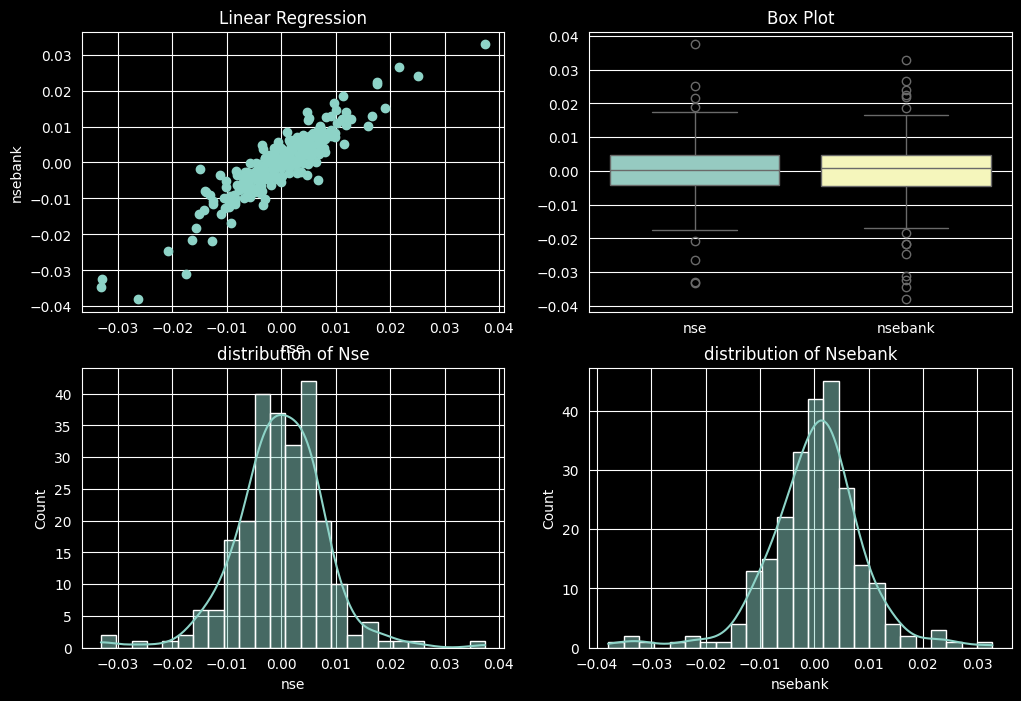

In [46]:
end = dt.date.today()
start = dt.date.today() - dt.timedelta(days=365)
df = yf.download(['^Nsei','^NSEBANK'],start,end)['Close']
df['nse'] = np.log(df['^NSEI'] / df['^NSEI'].shift(1))
df['nsebank'] = np.log(df['^NSEBANK'] / df['^NSEBANK'].shift(1))
df.drop(columns=['^NSEI','^NSEBANK'], inplace=True)

# drop nans
df.dropna(inplace=True)

# Assign X and Y
x = df['nse']
y = df['nsebank']

# Plotting
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.scatter(x,y)
plt.xlabel('nse')
plt.ylabel('nsebank')
plt.title('Linear Regression')

# outlier detection
plt.subplot(2,2,2)
sns.boxplot(data = [x,y])
plt.title('Box Plot')

# histogram + kde
plt.subplot(2,2,3)
sns.histplot(x,kde=True)
plt.title('distribution of Nse')

plt.subplot(2,2,4)
sns.histplot(y,kde=True)
plt.title('distribution of Nsebank')
plt.show()

In [47]:
# Model
x = sm.add_constant(x)

model = sm.OLS(y,x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                nsebank   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     1208.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.79e-96
Time:                        08:09:29   Log-Likelihood:                 1030.1
No. Observations:                 246   AIC:                            -2056.
Df Residuals:                     244   BIC:                            -2049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.888      0.3

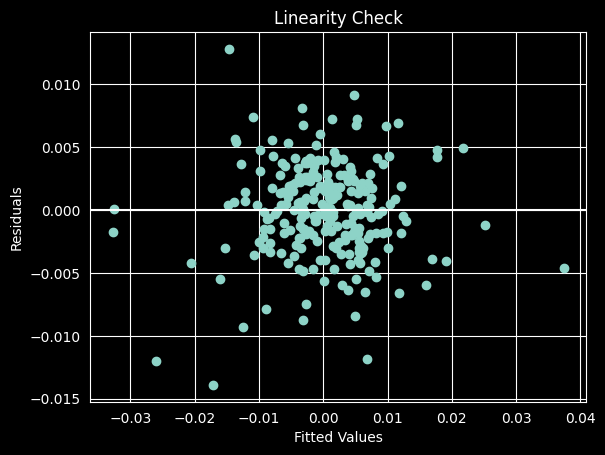

In [49]:
residuals = model.resid

fitted = model.fittedvalues

# Linearity Check
plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Linearity Check")
plt.show()

In [56]:
# Autocorrelation
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)
print("Durbin-Watson:", dw)

Durbin-Watson: 1.8178622107127915


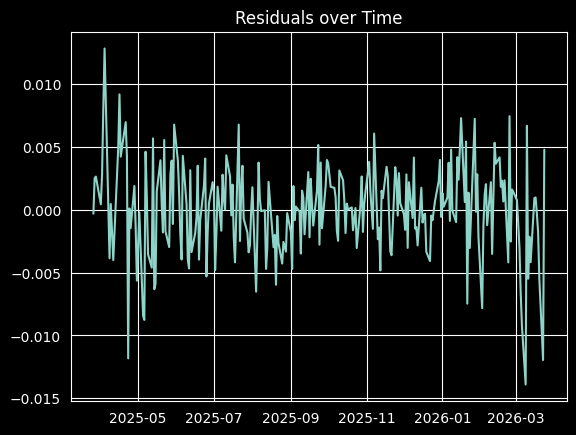

In [51]:
plt.plot(residuals)
plt.title("Residuals over Time")
plt.show()

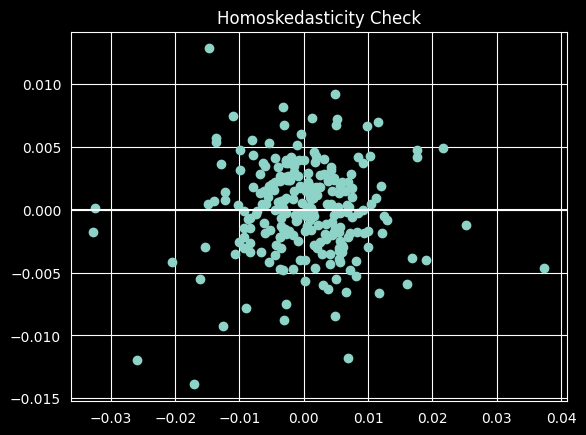

In [52]:
plt.scatter(fitted, residuals)
plt.axhline(0)
plt.title("Homoskedasticity Check")
plt.show()

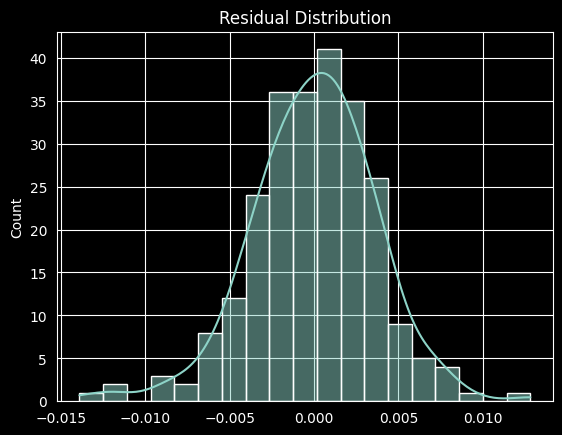

In [53]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

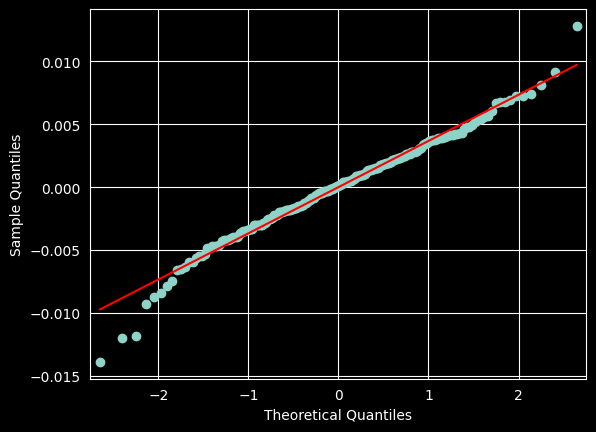

1.2964639714977295
-0.31622146222976605


In [58]:
sm.qqplot(residuals, line='s')
plt.show()

from scipy.stats import kurtosis

print(kurtosis(residuals))

from scipy.stats import skew
print(skew(residuals))

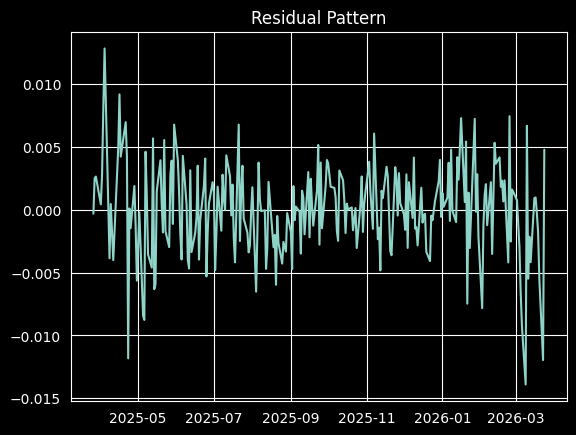

In [55]:
plt.plot(residuals)
plt.title("Residual Pattern")
plt.show()

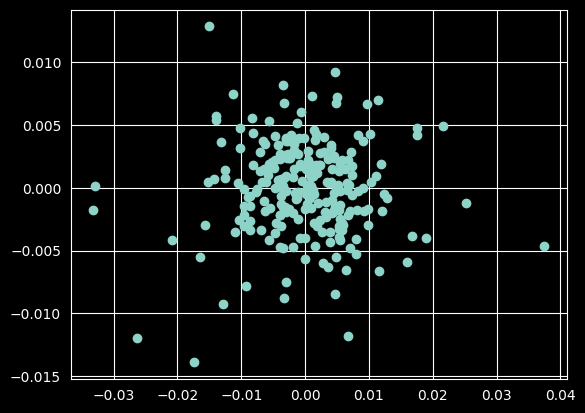

In [62]:
plt.scatter(model.model.exog[:,1], model.resid)

In [63]:
model_robust = model.get_robustcov_results()
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                nsebank   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     676.9
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           2.53e-72
Time:                        08:51:30   Log-Likelihood:                 1030.1
No. Observations:                 246   AIC:                            -2056.
Df Residuals:                     244   BIC:                            -2049.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.892      0.3

In [65]:
threshold = 3 * residuals.std()

filtered_data = df[np.abs(residuals) < threshold]

x_new = filtered_data['nse']
y_new = filtered_data['nsebank']

In [66]:
x_const_new = sm.add_constant(x_new)
model_new = sm.OLS(y_new, x_const_new).fit()

print(model_new.summary())

                            OLS Regression Results                            
Dep. Variable:                nsebank   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     1313.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           2.65e-99
Time:                        08:51:57   Log-Likelihood:                 1037.7
No. Observations:                 242   AIC:                            -2071.
Df Residuals:                     240   BIC:                            -2064.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.460      0.1

In [67]:
df['nse_lag1'] = df['nse'].shift(1)
df.dropna(inplace=True)

X = df[['nse', 'nse_lag1']]
Y = df['nsebank']

X = sm.add_constant(X)
model_lag = sm.OLS(Y, X).fit()

print(model_lag.summary())

                            OLS Regression Results                            
Dep. Variable:                nsebank   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     607.5
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           4.57e-95
Time:                        08:52:30   Log-Likelihood:                 1027.3
No. Observations:                 245   AIC:                            -2049.
Df Residuals:                     242   BIC:                            -2038.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.944      0.3